## Reinforcement Learning

The next and final topic in this course covers *Reinforcement Learning*. This technique is different than many of the other machine learning techniques we have seen earlier and has many applications in training agents (an AI) to interact with enviornments like games. Rather than feeding our machine learning model millions of examples we let our model come up with its own examples by exploring an enviornemt. The concept is simple. Humans learn by exploring and learning from mistakes and past experiences so let's have our computer do the same.



### Terminology

Before we dive into explaining reinforcement learning we need to define a few key peices of terminology.

**Enviornemt** In reinforcement learning tasks we have a notion of the enviornment. This is what our *agent* will explore. An example of an enviornment in the case of training an AI to play say a game of mario would be the level we are training the agent on.

**Agent** an agent is an entity that is exploring the enviornment. Our agent will interact and take different actions within the enviornment. In our mario example the mario character within the game would be our agent.

**State** always our agent will be in what we call a *state*. The state simply tells us about the status of the agent. The most common example of a state is the location of the agent within the enviornment. Moving locations would change the agents state.

**Action** any interaction between the agent and enviornment would be considered an action. For example, moving to the left or jumping would be an action. An action may or may not change the current *state* of the agent. In fact, the act of doing nothing is an action as well! The action of say not pressing a key if we are using our mario example.

**Reward** every action that our agent takes will result in a reward of some magnitude (positive or negative). The goal of our agent will be to maximize its reward in an enviornment. Sometimes the reward will be clear, for example if an agent performs an action which increases their score in the enviornment we could say they've recieved a positive reward. If the agent were to perform an action which results in them losing score or possibly dying in the enviornment then they would recieve a negative reward.

The most important part of reinforcement learning is determing how to reward the agent. After all, the goal of the agent is to maximize its rewards. This means we should reward the agent appropiatly such that it reaches the desired goal.



### Q-Learning

Now that we have a vague idea of how reinforcement learning works it's time to talk about a specific technique in reinforcement learning called *Q-Learning*.

Q-Learning is a simple yet quite powerful technique in machine learning that involves learning a matrix of action-reward values. This matrix is often reffered to as a Q-Table or Q-Matrix. The matrix is in shape (number of possible states, number of possible actions) where each value at matrix[n, m] represents the agents expected reward given they are in state n and take action m. The Q-learning algorithm defines the way we update the values in the matrix and decide what action to take at each state. The idea is that after a succesful training/learning of this Q-Table/matrix we can determine the action an agent should take in any state by looking at that states row in the matrix and taking the maximium value column as the action.

**Consider this example.**

Let's say A1-A4 are the possible actions and we have 3 states represented by each row (state 1 - state 3).

| A1  | A2  | A3  | A4  |
|:--: |:--: |:--: |:--: |
|  0  |  0  | 10  |  5  |
|  5  | 10  |  0  |  0  |
| 10  |  5  |  0  |  0  |

If that was our Q-Table/matrix then the following would be the preffered actions in each state.

> State 1: A3

> State 2: A2

> State 3: A1

We can see that this is because the values in each of those columns are the highest for those states!



### Learning the Q-Table

So that's simple, right? Now how do we create this table and find those values. Well this is where we will dicuss how the Q-Learning algorithm updates the values in our Q-Table.

I'll start by noting that our Q-Table starts of with all 0 values. This is because the agent has yet to learn anything about the enviornment.

Our agent learns by exploring the enviornment and observing the outcome/reward from each action it takes in each state. But how does it know what action to take in each state? There are two ways that our agent can decide on which action to take.
1. Randomly picking a valid action
2. Using the current Q-Table to find the best action.

Near the beginning of our agents learning it will mostly take random actions in order to explore the enviornment and enter many different states. As it starts to explore more of the enviornment it will start to gradually rely more on it's learned values (Q-Table) to take actions. This means that as our agent explores more of the enviornment it will develop a better understanding and start to take "correct" or better actions more often. It's important that the agent has a good balance of taking random actions and using learned values to ensure it does get trapped in a local maximum.

After each new action our agent wil record the new state (if any) that it has entered and the reward that it recieved from taking that action. These values will be used to update the Q-Table. The agent will stop taking new actions only once a certain time limit is reached or it has acheived the goal or reached the end of the enviornment.

#### Updating Q-Values

The formula for updating the Q-Table after each action is as follows:
> $ Q[state, action] = Q[state, action] + \alpha * (reward + \gamma * max(Q[newState, :]) - Q[state, action]) $

- $\alpha$ stands for the **Learning Rate**

- $\gamma$ stands for the **Discount Factor**

#### Learning Rate $\alpha$
The learning rate $\alpha$ is a numeric constant that defines how much change is permitted on each QTable update. A high learning rate means that each update will introduce a large change to the current state-action value. A small learning rate means that each update has a more subtle change. Modifying the learning rate will change how the agent explores the enviornment and how quickly it determines the final values in the QTable.

#### Discount Factor $\gamma$
Discount factor also know as gamma ($\gamma$) is used to balance how much focus is put on the current and future reward. A high discount factor means that future rewards will be considered more heavily.

<br/>
<p>To perform updates on this table we will let the agent explpore the enviornment for a certain period of time and use each of its actions to make an update. Slowly we should start to notice the agent learning and choosing better actions. </p>



## Q-Learning Example
For this example we will use the Q-Learning algorithm to train an agent to navigate a popular enviornment from the [Open AI Gym](https://gym.openai.com/). The Open AI Gym was developed so programmers could practice machine learning using unique enviornments. Intersting fact, Elon Musk is one of the founders of OpenAI!

Let's start by looking at what Open AI Gym is.

### Frozen Lake Enviornment

Now that we have a basic understanding of how the gym enviornment works it's time to discuss the specific problem we will be solving.

The enviornment we loaded above ```FrozenLake-v0``` is one of the simplest enviornments in Open AI Gym. The goal of the agent is to navigate a frozen lake and find the Goal without falling through the ice (render the enviornment above to see an example).

There are:
- 16 states (one for each square)
- 4 possible actions (LEFT, RIGHT, DOWN, UP)
- 4 different types of blocks (F: frozen, H: hole, S: start, G: goal)



Episode 200/2000 | Avg Reward: 0.015 | Epsilon: 0.367
Episode 400/2000 | Avg Reward: 0.060 | Epsilon: 0.135
Episode 600/2000 | Avg Reward: 0.180 | Epsilon: 0.049
Episode 800/2000 | Avg Reward: 0.430 | Epsilon: 0.018
Episode 1000/2000 | Avg Reward: 0.505 | Epsilon: 0.010
Episode 1200/2000 | Avg Reward: 0.520 | Epsilon: 0.010
Episode 1400/2000 | Avg Reward: 0.535 | Epsilon: 0.010
Episode 1600/2000 | Avg Reward: 0.525 | Epsilon: 0.010
Episode 1800/2000 | Avg Reward: 0.610 | Epsilon: 0.010
Episode 2000/2000 | Avg Reward: 0.605 | Epsilon: 0.010


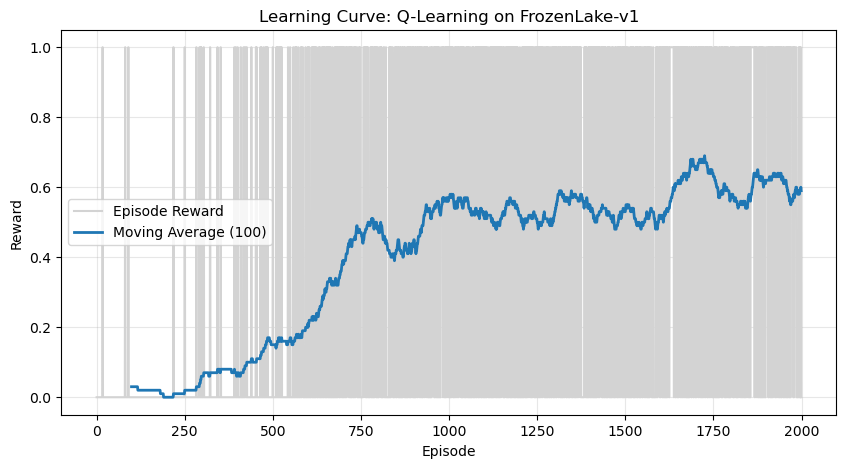

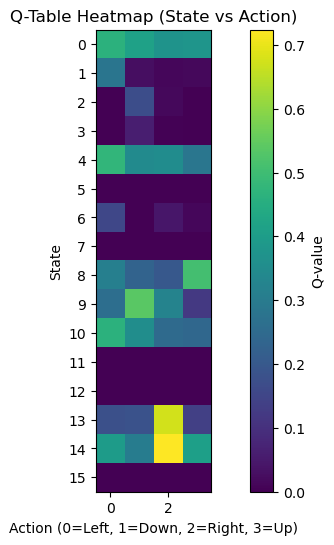

Success rate over 100 episodes: 0.59


In [1]:
# 5_Reinforcement_Learning.ipynb (Q-Learning FrozenLake – Gymnasium)
# -------------------------------------------------
# Clean academic-style Q-Learning implementation for FrozenLake-v1
# Gymnasium-compatible + logging + reward curve

# =================================================
# 1. Imports
# =================================================
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# =================================================
# 2. Environment Setup (FrozenLake)
# =================================================
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True
)

n_states = env.observation_space.n   # 16 states
n_actions = env.action_space.n       # 4 actions

# =================================================
# 3. Q-Table Initialization
# =================================================
Q = np.zeros((n_states, n_actions))

# =================================================
# 4. Hyperparameters
# =================================================
alpha = 0.1            # learning rate
gamma = 0.99           # discount factor
epsilon = 1.0          # exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
num_episodes = 2000

# =================================================
# 5. Training Loop (Gymnasium API)
# =================================================
rewards_log = []

for episode in range(num_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        # Epsilon-greedy policy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-Learning update rule
        best_next_action = np.max(Q[next_state])
        Q[state, action] += alpha * (
            reward + gamma * best_next_action - Q[state, action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_log.append(total_reward)

    if (episode + 1) % 200 == 0:
        avg_reward = np.mean(rewards_log[-200:])
        print(f"Episode {episode+1}/{num_episodes} | Avg Reward: {avg_reward:.3f} | Epsilon: {epsilon:.3f}")

# =================================================
# 6. Reward Curve Visualization (Readable)
# =================================================
# Convert to numpy for easier processing
rewards_np = np.array(rewards_log)

# Smoothed reward using moving average
window = 100
smoothed_rewards = np.convolve(
    rewards_np,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(rewards_np, color="lightgray", label="Episode Reward")
plt.plot(
    range(window - 1, len(rewards_np)),
    smoothed_rewards,
    linewidth=2,
    label=f"Moving Average ({window})"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Learning Curve: Q-Learning on FrozenLake-v1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =================================================
# 6b. Q-Table Visualization (Heatmap)
# =================================================
plt.figure(figsize=(10, 6))
plt.imshow(Q, cmap="viridis")
plt.colorbar(label="Q-value")
plt.xlabel("Action (0=Left, 1=Down, 2=Right, 3=Up)")
plt.ylabel("State")
plt.title("Q-Table Heatmap (State vs Action)")
plt.yticks(range(n_states))
plt.show()

# =================================================
# 7. Evaluation (Greedy Policy)
# =================================================

# =================================================
eval_episodes = 100
success = 0

for _ in range(eval_episodes):
    state, _ = env.reset()
    done = False

    while not done:
        action = np.argmax(Q[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        if reward == 1:
            success += 1

print(f"Success rate over {eval_episodes} episodes: {success / eval_episodes:.2f}")

env.close()

## Sources
1. Violante, Andre. “Simple Reinforcement Learning: Q-Learning.” Medium, Towards Data Science, 1 July 2019, https://towardsdatascience.com/simple-reinforcement-learning-q-learning-fcddc4b6fe56.

2. Openai. “Openai/Gym.” GitHub, https://github.com/openai/gym/wiki/FrozenLake-v0.